## **1. Installing Required Libraries**


In [1]:
!pip install wfdb
!pip install umap-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 120.5 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.1 which is incompatible.
dask-cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.1 which is incompatible.
cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.1 which is incompatible.


## **2. Importing Required Libraries**

In [2]:
import numpy as np
import scipy.signal
from skimage.transform import resize
import wfdb
import scipy
from umap import UMAP
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.manifold import trustworthiness
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import pickle
import os
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.patches as mpatches
from sklearn.metrics import f1_score
from skimage.filters import sobel
from skimage import measure, morphology
from collections import Counter
from sklearn.cluster import DBSCAN
import matplotlib.lines as mlines

## **3. Mounting my Google Drive**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **4. Functions**

### **4.1 Loading ECG Signal**

In [22]:
def loading_ECG_signal(Record_number, record_path_base, fs=360):
    """
    Load and preprocess ECG signals and compute FFT of each heartbeat.

    Args:
        Record_number (int): MIT-BIH record number.
        record_path_base (str): Base directory path where records are stored.
        fs (float): Sampling frequency in Hz (default 256).

    Returns:
        ECG_signal_MLII_filtered (np.ndarray): Shape (num_beats, 256).
        ECG_signal_V1_filtered (np.ndarray): Shape (num_beats, 256).
        ECG_signal_concatenated (np.ndarray): Shape (num_beats, 512).
        beat_symbols (np.ndarray): Beat labels.
        label_AAMI_superclass (np.ndarray): AAMI class labels.
        metadata (dict): Metadata dictionary.
    """

    record_path = record_path_base + str(Record_number)
    signals, fields = wfdb.rdsamp(record_path)
    annotation = wfdb.rdann(record_path, 'atr')

    comments = fields['comments']
    age = int(comments[0].split()[0])
    sex_text = comments[0].split()[1]
    sex = 0 if sex_text == 'M' else 1
    sig_name = fields['sig_name']

    sample_indices = np.array(annotation.sample)
    symbols = np.array(annotation.symbol)
    valid_idx = np.arange(1, len(sample_indices) - 1)
    r_peaks = sample_indices[valid_idx]
    prev_r_peaks = sample_indices[valid_idx - 1]
    next_r_peaks = sample_indices[valid_idx + 1]
    beat_symbols = symbols[valid_idx]

    segment_starts = r_peaks - np.round((r_peaks - prev_r_peaks) / 3).astype(int)
    segment_ends = r_peaks + np.round(2 * (next_r_peaks - r_peaks) / 3).astype(int)

    ECG_signal_MLII_filtered = np.zeros((len(r_peaks), 256))
    ECG_signal_V1_filtered = np.zeros((len(r_peaks), 256))
    ECG_signal_concatenated = np.zeros((len(r_peaks), 512))

    for i in range(len(r_peaks)):
        seg1 = resize(signals[segment_starts[i]:segment_ends[i], 0], (256,), anti_aliasing=True)
        seg2 = resize(signals[segment_starts[i]:segment_ends[i], 1], (256,), anti_aliasing=True)

        filt1 = seg1 - scipy.signal.medfilt(seg1, kernel_size=127)
        filt2 = seg2 - scipy.signal.medfilt(seg2, kernel_size=127)

        concat = np.concatenate((filt1, filt2))

        ECG_signal_MLII_filtered[i] = filt1
        ECG_signal_V1_filtered[i] = filt2
        ECG_signal_concatenated[i] = concat

    AAMI_map = {
        'N': 0, '.': 0, 'L': 0, 'R': 0, 'e': 0, 'j': 0,
        'V': 1, 'E': 1,
        'A': 2, 'S': 2, 'J': 2, 'a': 2,
        'F': 3,
        'Q': 4, '/': 4, 'f': 4
    }
    label_AAMI_superclass = np.array([AAMI_map.get(sym, 5) for sym in beat_symbols])

    metadata = {
        'Record_number': Record_number,
        'age': age,
        'sex': sex,
        'sex_text': sex_text,
        'sig_name': sig_name,
        'comments': comments
    }

    print("MLII Filtered Signals Shape: ", ECG_signal_MLII_filtered.shape)
    print("V1 Filtered Signals Shape: ", ECG_signal_V1_filtered.shape)
    print("Concatenated Signals Shape: ", ECG_signal_concatenated.shape)
    print("MIT-BIH Labels Shape: ", beat_symbols.shape)
    print("AAMI Labels Shape: ", label_AAMI_superclass.shape)

    return (
        ECG_signal_MLII_filtered,
        ECG_signal_V1_filtered,
        ECG_signal_concatenated,
        beat_symbols,
        label_AAMI_superclass,
        metadata
    )


### **4.2 Dimensionality Reduction**

In [23]:
def compute_embeddings(modality_1, modality_2, min_dist=0.1, n_neighbors=15, random_state=42, perplexity=30.0):
    """
    Compute UMAP, t-SNE, and PCA embeddings for each modality.

    Args:
        modality_1 (np.ndarray): Signals for modality 1, shape (num_samples, num_features).
        modality_2 (np.ndarray): Signals for modality 2, shape (num_samples, num_features).

    Returns:
        dict: Dictionary containing embeddings:
            - umap_modality_1, umap_modality_2
            - tsne_modality_1, tsne_modality_2
            - pca_modality_1, pca_modality_2
    """

    # Define UMAP
    ump = UMAP(
        n_components=2,
        min_dist=min_dist,
        n_neighbors=n_neighbors,
        random_state=random_state,
        init='pca'  # options: 'spectral'
    )

    # Define t-SNE
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=random_state,
        init='pca'
    )

    # Define PCA
    pca = PCA(
        n_components=2,
        random_state=random_state
    )

    # Compute UMAP embeddings
    umap_modality_1 = ump.fit_transform(modality_1)
    umap_modality_2 = ump.fit_transform(modality_2)

    # Compute t-SNE embeddings
    tsne_modality_1 = tsne.fit_transform(modality_1)
    tsne_modality_2 = tsne.fit_transform(modality_2)

    # Compute PCA embeddings
    pca_modality_1 = pca.fit_transform(modality_1)
    pca_modality_2 = pca.fit_transform(modality_2)

    return  umap_modality_1, umap_modality_2, tsne_modality_1, tsne_modality_2, pca_modality_1, pca_modality_2

### **4.3 Clustering Algorithm**

In [24]:
def clustering_with_image_segmentation(points, image_size=(256, 256), radius=3):
    scatter_image = np.zeros(image_size, dtype=np.uint8)

    # Normalize points
    x_min, x_max = np.min(points[:, 0]), np.max(points[:, 0])
    y_min, y_max = np.min(points[:, 1]), np.max(points[:, 1])
    normalized_points = []
    for point in points:
        x, y = point
        normalized_x = int((x - x_min) / (x_max - x_min) * (image_size[1] - 1))
        normalized_y = int((y - y_min) / (y_max - y_min) * (image_size[0] - 1))
        normalized_points.append((normalized_x, normalized_y))

    # Plot points
    for x, y in normalized_points:
        scatter_image[image_size[0] - 1 - y, x] = 255

    # Edge detection and closing
    edges = sobel(scatter_image) > 0
    closed_edges = morphology.binary_closing(edges, morphology.disk(radius))

    # Label clusters
    labeled_clusters, _ = measure.label(closed_edges, return_num=True)

    # Get original point labels
    point_labels = []
    for x, y in normalized_points:
        label = labeled_clusters[image_size[0] - 1 - y, x]
        point_labels.append(label)

    # Sort labels by cluster size
    label_counts = Counter(point_labels)
    sorted_labels = [label for label, _ in label_counts.most_common()]
    label_mapping = {old: new for new, old in enumerate(sorted_labels)}

    # Reassign labels to be sorted
    sorted_point_labels = [label_mapping[label] for label in point_labels]

    return scatter_image, edges, closed_edges, labeled_clusters, np.array(sorted_point_labels), sorted_labels


### **4.4 Do it on one Sample**

#### **4.4.1 Loading**

In [37]:
# MIT-BIH
record_base_path = '/content/drive/MyDrive/Imaging Physics Group/Heart Arrhythmia Detection/mitdb/'
Record_number_list = [101, 105, 106, 107, 108, 109, 111, 112, 113, 115, 116, 118, 119, 121, 122,
                      200, 201, 202, 203, 205, 207, 208, 209, 210, 212, 213, 214, 215, 217, 219,
                      220, 221, 222, 223, 228, 230, 231, 232, 233, 234]
Record_number = 207
fs = 360

# NSR-DB
# record_number_list = ['16265', '16272', '16273', '16420', '16483', '16539', '16773', '16786', '16795', '17052',
#                      '17453', '18177', '18184', '19088', '19090', '19093', '19140', '19830']
# record_base_path = '/content/drive/MyDrive/Imaging Physics Group/Heart Arrhythmia Detection/NSRDB/'
# Record_number = '16272'
# fs = 128

# Load signals
(
    ECG_MLII,
    ECG_V1,
    ECG_concat,
    mitbih_labels,
    aami_labels,
    meta,
) = loading_ECG_signal(Record_number=Record_number, record_path_base=record_base_path, fs=fs)

MLII Filtered Signals Shape:  (2383, 256)
V1 Filtered Signals Shape:  (2383, 256)
Concatenated Signals Shape:  (2383, 512)
MIT-BIH Labels Shape:  (2383,)
AAMI Labels Shape:  (2383,)


#### **4.4.2 Calculating PCA, t-SNE, UMAP**

In [38]:
# Calculating Embeddings
umap_mlii, umap_v1, tsne_mlii, tsne_v1, pca_mlii, pca_v1 = compute_embeddings(ECG_MLII, ECG_V1, min_dist=0.1, n_neighbors=15, random_state=42)

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


#### **4.4.3 Visualization**

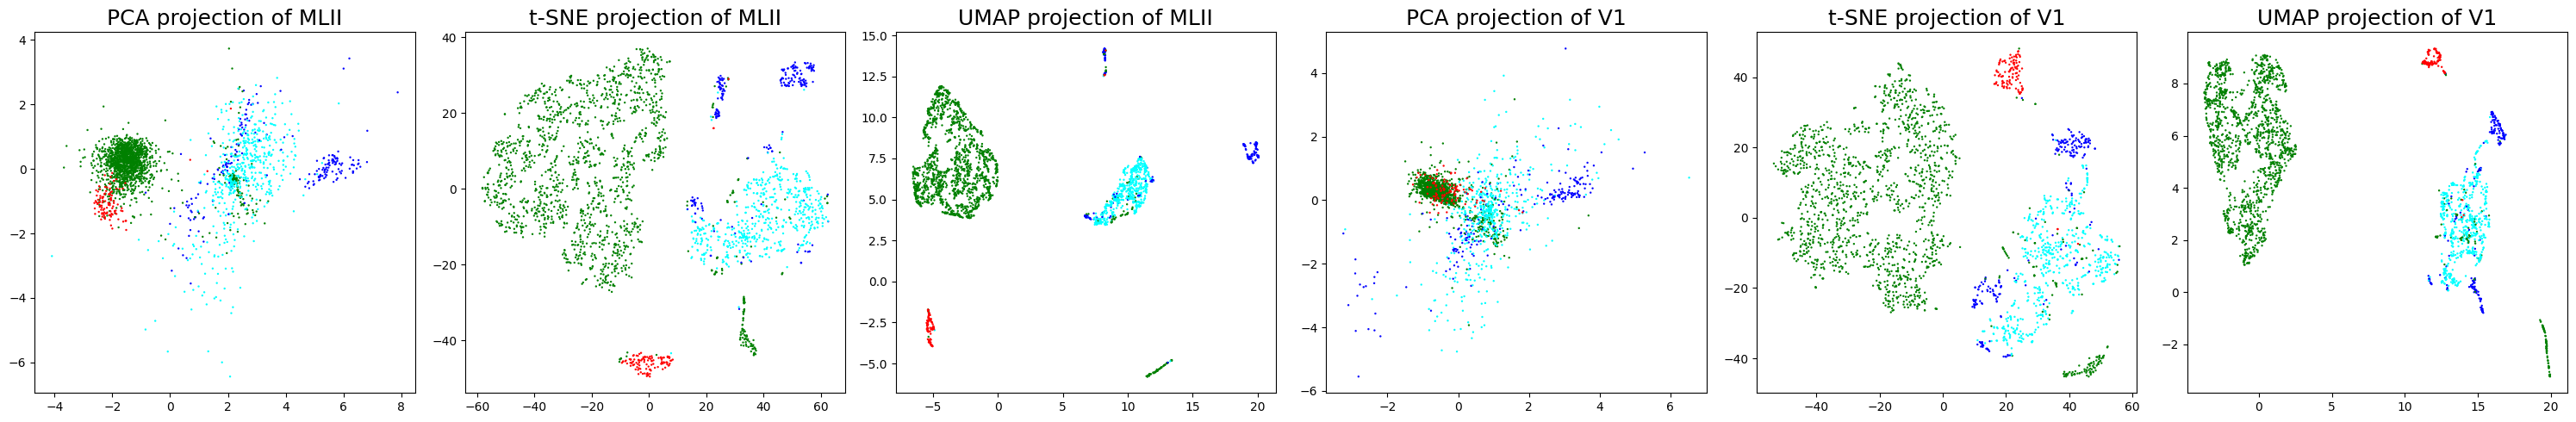

In [39]:
# Colormap for classes
colors = ['green', 'blue', 'red', 'purple', 'orange', 'cyan']
cmap = mcolors.ListedColormap(colors)
classes = ['Normal', 'Ventricular Ectopic Beat', 'Supraventricular Ectopic Beat', 'Fusion Beat', 'Unknown', 'Others']

# Plot 1x6 subplots
fig, axes = plt.subplots(1, 6, figsize=(30, 5))

# PCA - MLII
axes[0].scatter(pca_mlii[:, 0], pca_mlii[:, 1], c=aami_labels, cmap=cmap, s=0.5)
axes[0].set_title('PCA projection of MLII', fontsize=18)

# t-SNE - MLII
axes[1].scatter(tsne_mlii[:, 0], tsne_mlii[:, 1], c=aami_labels, cmap=cmap, s=0.5)
axes[1].set_title('t-SNE projection of MLII', fontsize=18)

# UMAP - MLII
axes[2].scatter(umap_mlii[:, 0], umap_mlii[:, 1], c=aami_labels, cmap=cmap, s=0.5)
axes[2].set_title('UMAP projection of MLII', fontsize=18)

# PCA - V1
axes[3].scatter(pca_v1[:, 0], pca_v1[:, 1], c=aami_labels, cmap=cmap, s=0.5)
axes[3].set_title('PCA projection of V1', fontsize=18)

# t-SNE - V1
axes[4].scatter(tsne_v1[:, 0], tsne_v1[:, 1], c=aami_labels, cmap=cmap, s=0.5)
axes[4].set_title('t-SNE projection of V1', fontsize=18)

# UMAP - V1
axes[5].scatter(umap_v1[:, 0], umap_v1[:, 1], c=aami_labels, cmap=cmap, s=0.5)
axes[5].set_title('UMAP projection of V1', fontsize=18)

plt.tight_layout()
plt.show()

#### **4.4.4 KNN**

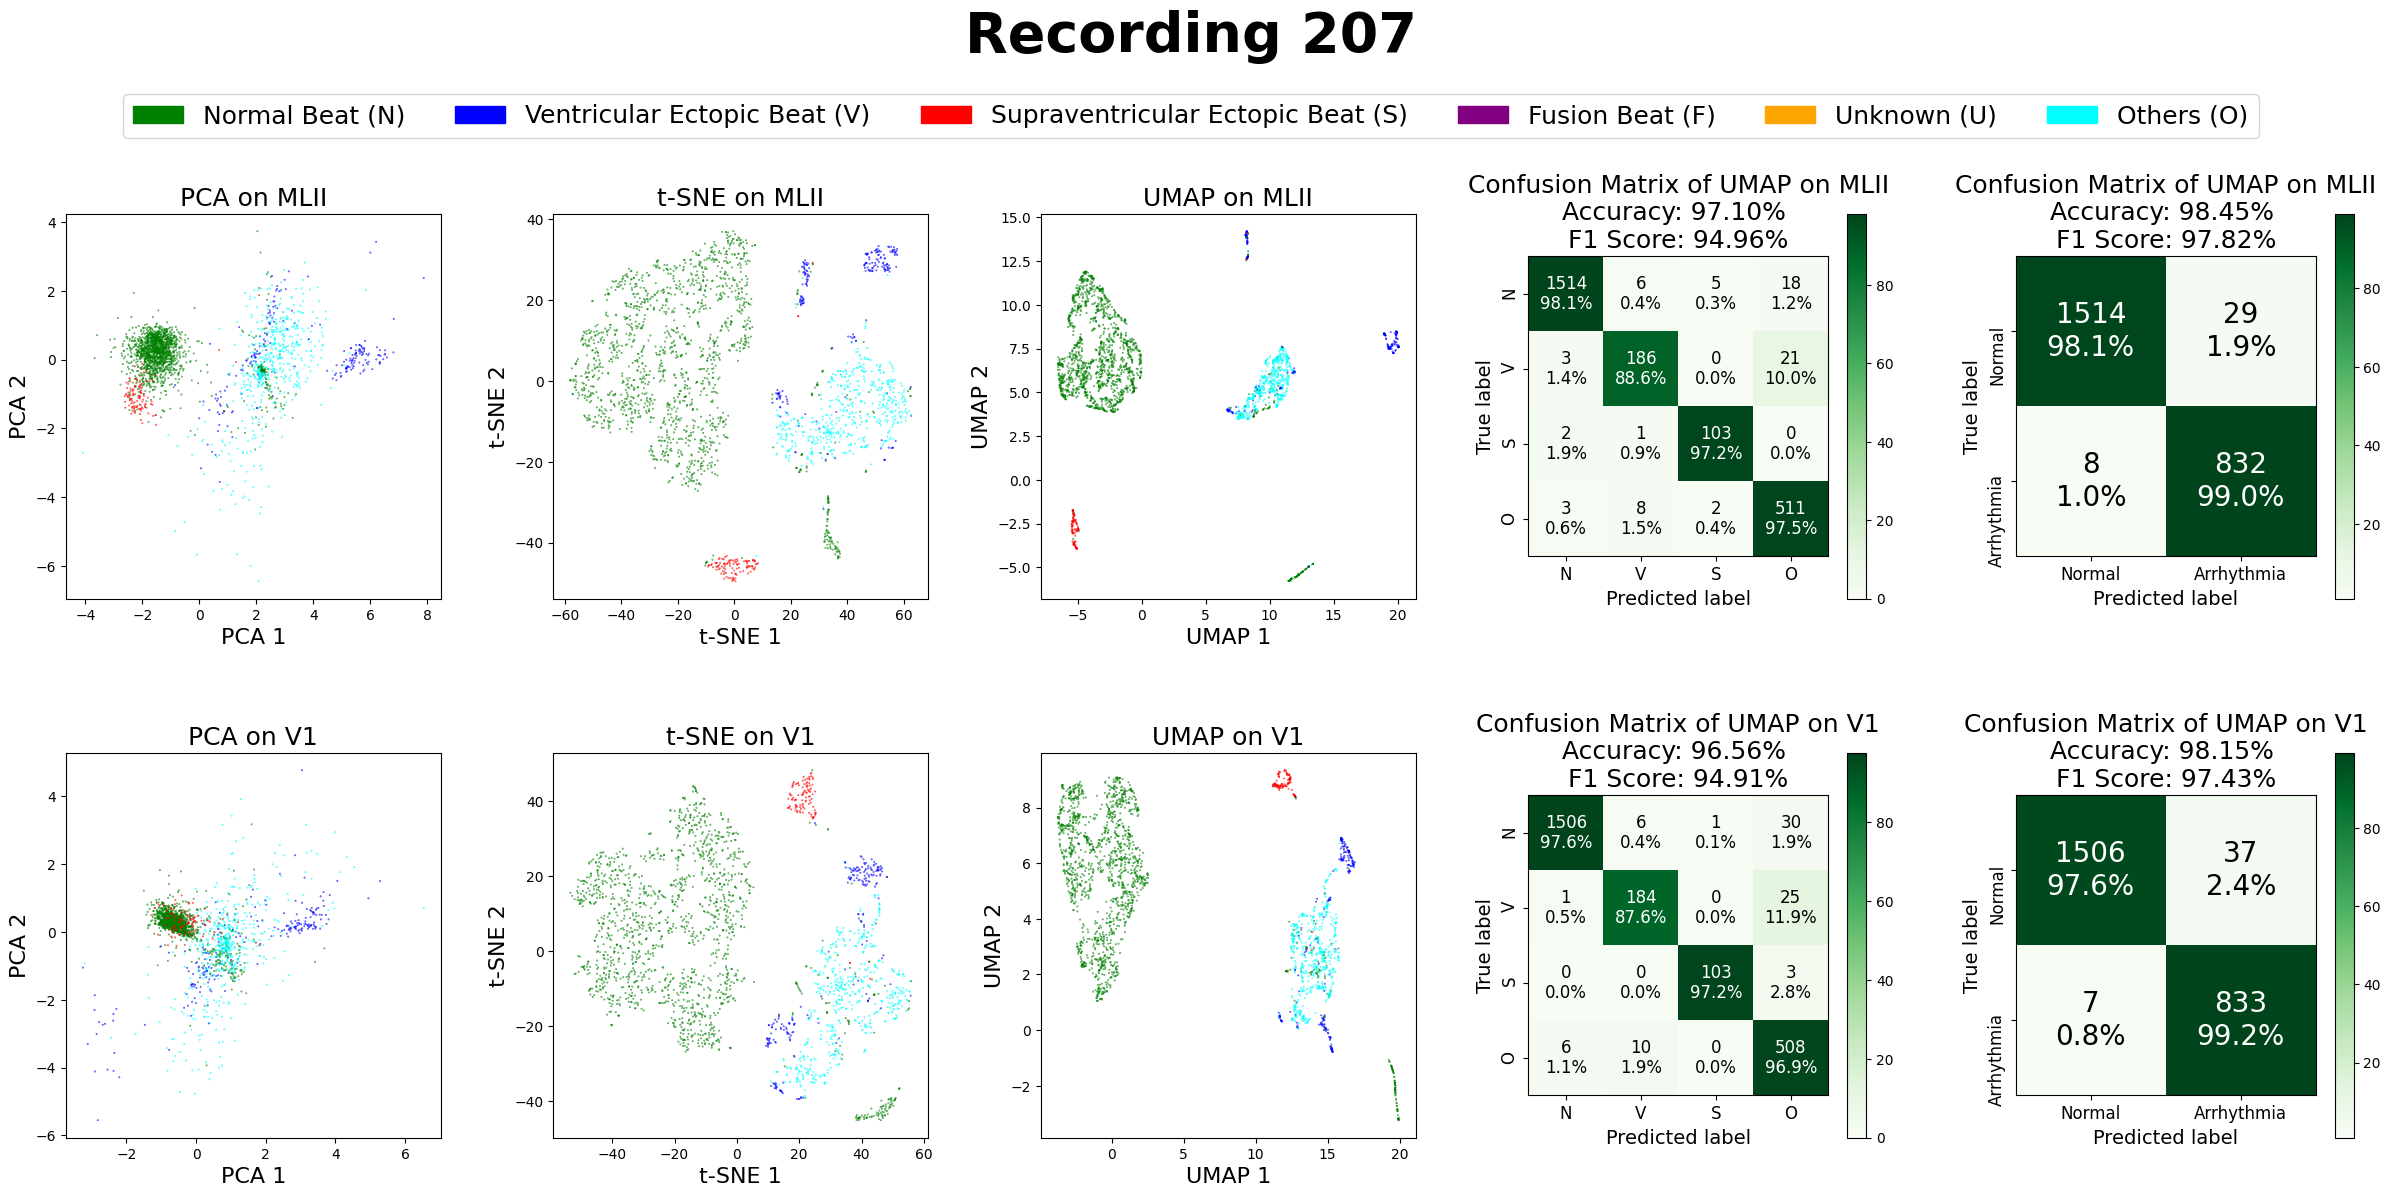

In [40]:
# Setup
i = Record_number_list.index(Record_number)

# Labels and colors
colors = ['green', 'blue', 'red', 'purple', 'orange', 'cyan']
classes = ['Normal Beat (N)', 'Ventricular Ectopic Beat (V)', 'Supraventricular Ectopic Beat (S)', 'Fusion Beat (F)', 'Unknown (U)', 'Others (O)']
classes_confusion = ['N', 'V', 'S', 'F', 'U', 'O']
cmap = mcolors.ListedColormap(colors)
font_size = 18

# Legend handles
legend_handles = [mpatches.Patch(color=colors[i], label=classes[i]) for i in range(len(classes))]

# Extract data
ecg_labels = aami_labels
proj_MLII = [pca_mlii, tsne_mlii, umap_mlii]
proj_V1 = [pca_v1, tsne_v1, umap_v1]
titles = ['PCA', 't-SNE', 'UMAP']

# Create figure
fig, axes = plt.subplots(2, 5, figsize=(30, 12))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

def plot_projection(ax, data, label, method, lead):
    ax.scatter(data[:, 0], data[:, 1], s=0.1, c=label, cmap=cmap)
    ax.set_title(f'{method} on {lead}', fontsize=font_size)
    ax.set_xlabel(f'{method} 1', fontsize=font_size-2)
    ax.set_ylabel(f'{method} 2', fontsize=font_size-2)
    ax.grid(False)

def plot_multiclass_confusion(ax, X, true_labels, method, lead):
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X, true_labels)
    pred = knn.predict(X)
    cm = confusion_matrix(true_labels, pred, labels=range(len(colors)))
    present = np.unique(true_labels)
    cm_filt = cm[present][:, present]
    cm_pct = cm_filt.astype(float) / cm_filt.sum(axis=1)[:, np.newaxis] * 100
    im = ax.imshow(cm_pct, cmap='Greens')

    for r in range(len(present)):
        for c in range(len(present)):
            color = 'white' if cm_pct[r, c] > 50 else 'black'
            ax.text(c, r, f"{cm_filt[r,c]}\n{cm_pct[r,c]:.1f}%", ha='center', va='center', color=color, fontsize=12)

    ax.set_xticks(np.arange(len(present)))
    ax.set_yticks(np.arange(len(present)))
    ax.set_xticklabels([classes_confusion[k] for k in present], rotation=0, fontsize=12)
    ax.set_yticklabels([classes_confusion[k] for k in present], rotation=90, fontsize=12)
    ax.set_xlabel('Predicted label', fontsize=14)
    ax.set_ylabel('True label', fontsize=14)
    acc = np.trace(cm_filt) / cm_filt.sum() * 100
    f1 = f1_score(true_labels, pred, average='macro') * 100
    ax.set_title(f'Confusion Matrix of {method} on {lead}\nAccuracy: {acc:.2f}% \nF1 Score: {f1:.2f}%', fontsize=font_size)
    return pred, im

def plot_binary_confusion(ax, true_labels, predicted_labels, method, lead):
    true_bin = np.array([0 if l == 0 else 1 for l in true_labels])
    pred_bin = np.array([0 if l == 0 else 1 for l in predicted_labels])
    cm_bin = confusion_matrix(true_bin, pred_bin, labels=[0, 1])
    cm_pct = cm_bin.astype(float) / cm_bin.sum(axis=1)[:, np.newaxis] * 100
    im = ax.imshow(cm_pct, cmap='Greens')

    for r in range(2):
        for c in range(2):
            color = 'white' if cm_pct[r, c] > 50 else 'black'
            ax.text(c, r, f"{cm_bin[r,c]}\n{cm_pct[r,c]:.1f}%", ha='center', va='center', color=color, fontsize=20)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Normal', 'Arrhythmia'], rotation=0, fontsize=12)
    ax.set_yticklabels(['Normal', 'Arrhythmia'], rotation=90, fontsize=12)
    ax.set_xlabel('Predicted label', fontsize=14)
    ax.set_ylabel('True label', fontsize=14)
    acc = (cm_bin[0, 0] + cm_bin[1, 1]) / cm_bin.sum() * 100
    precision = cm_bin[1,1] / (cm_bin[1,1] + cm_bin[0,1]) if (cm_bin[1,1] + cm_bin[0,1]) > 0 else 0
    recall = cm_bin[1,1] / (cm_bin[1,1] + cm_bin[1,0]) if (cm_bin[1,1] + cm_bin[1,0]) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) * 100 if precision + recall > 0 else 0
    ax.set_title(f'Confusion Matrix of {method} on {lead}\nAccuracy: {acc:.2f}% \nF1 Score: {f1:.2f}%', fontsize=font_size)
    return im

# --- MLII Row ---
for col in range(3):
    plot_projection(axes[0, col], proj_MLII[col], ecg_labels, titles[col], 'MLII')

pred_ml, im_ml = plot_multiclass_confusion(axes[0, 3], proj_MLII[2], ecg_labels, 'UMAP', 'MLII')
fig.colorbar(im_ml, ax=axes[0, 3])

im_bin_ml = plot_binary_confusion(axes[0, 4], ecg_labels, pred_ml, 'UMAP', 'MLII')
fig.colorbar(im_bin_ml, ax=axes[0, 4])

# --- V1 Row ---
for col in range(3):
    plot_projection(axes[1, col], proj_V1[col], ecg_labels, titles[col], 'V1')

pred_v1, im_v1 = plot_multiclass_confusion(axes[1, 3], proj_V1[2], ecg_labels, 'UMAP', 'V1')
fig.colorbar(im_v1, ax=axes[1, 3])

im_bin_v1 = plot_binary_confusion(axes[1, 4], ecg_labels, pred_v1, 'UMAP', 'V1')
fig.colorbar(im_bin_v1, ax=axes[1, 4])

# Add title and legend
fig.suptitle(f"Recording {Record_number}", fontsize=40, y=1.05, fontweight='bold')
fig.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 0.99), ncol=6, fontsize=font_size)
plt.show()

#### **4.4.5 Clustering**

Labels sorted by size: [np.int32(2), np.int32(4), np.int32(5), np.int32(3), np.int32(6), np.int32(1)]


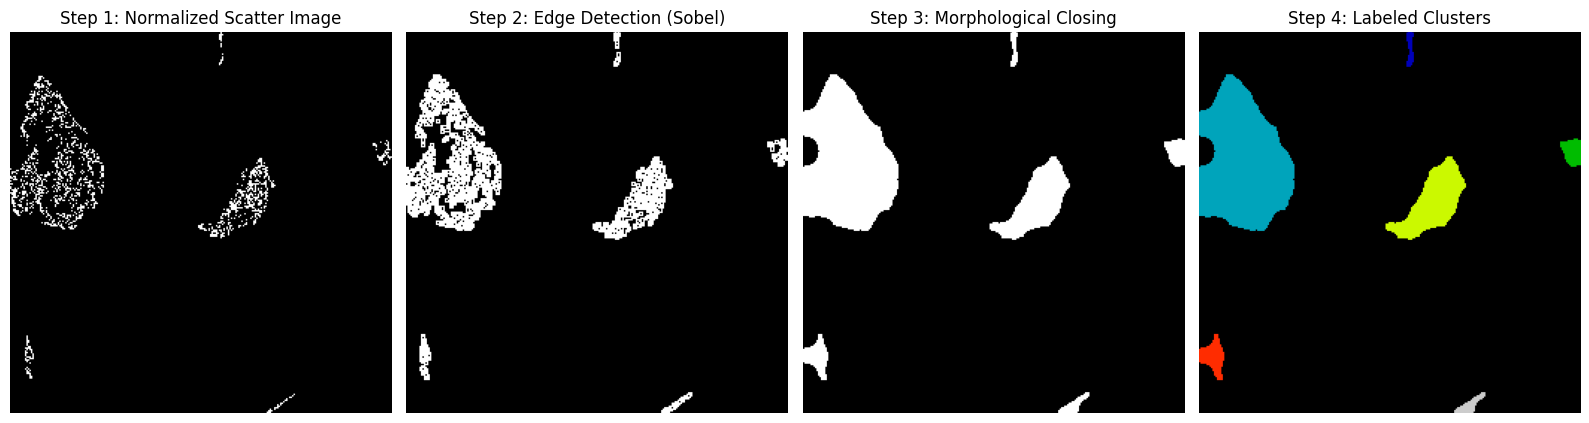

In [41]:
# Instance Segmentation Based Clustering Algorithm
channel = 'MLII'  # 'MLII' or 'V1'
dimensionality_reduction = 'UMAP'  # 'UMAP', 't-SNE'

if dimensionality_reduction == 'UMAP':
    if channel == 'V1':
        ecg_recording = ECG_V1
        y_selected = umap_v1
    elif channel == 'MLII':
        ecg_recording = ECG_MLII
        y_selected = umap_mlii

elif dimensionality_reduction == 't-SNE':
    if channel == 'V1':
        ecg_recording = ECG_V1
        y_selected = tsne_v1
    elif channel == 'MLII':
        ecg_recording = ECG_MLII
        y_selected = tsne_mlii


elif dimensionality_reduction == 'PCA':
    if channel == 'V1':
        ecg_recording = ECG_V1
        y_selected = pca_v1
    elif channel == 'MLII':
        ecg_recording = ECG_MLII
        y_selected = pca_mlii


# Applying our clustering algorithm
radius = 10
image_size = (256, 256)
y_selected = umap_mlii  # Replace with your data
# Run clustering
scatter_image, edges, closed_edges, labeled_clusters, point_labels, sorted_labels = clustering_with_image_segmentation(
    y_selected, image_size=image_size, radius=radius
)
print("Labels sorted by size:", sorted_labels)

fig2, axes = plt.subplots(1, 4, figsize=(16, 6))

# Plot each intermediate result in the same row
axes[0].imshow(scatter_image, cmap='gray')
axes[0].set_title("Step 1: Normalized Scatter Image")
axes[0].axis('off')

axes[1].imshow(edges, cmap='gray')
axes[1].set_title("Step 2: Edge Detection (Sobel)")
axes[1].axis('off')

axes[2].imshow(closed_edges, cmap='gray')
axes[2].set_title("Step 3: Morphological Closing")
axes[2].axis('off')

axes[3].imshow(labeled_clusters, cmap='nipy_spectral')
axes[3].set_title("Step 4: Labeled Clusters")
axes[3].axis('off')

# Save figure to the PDF
fig2.tight_layout()
plt.show()

# DBSCAN
clusterer_umap = DBSCAN(eps=5, min_samples=10)
labels_DBSCAN = clusterer_umap.fit_predict(y_selected)

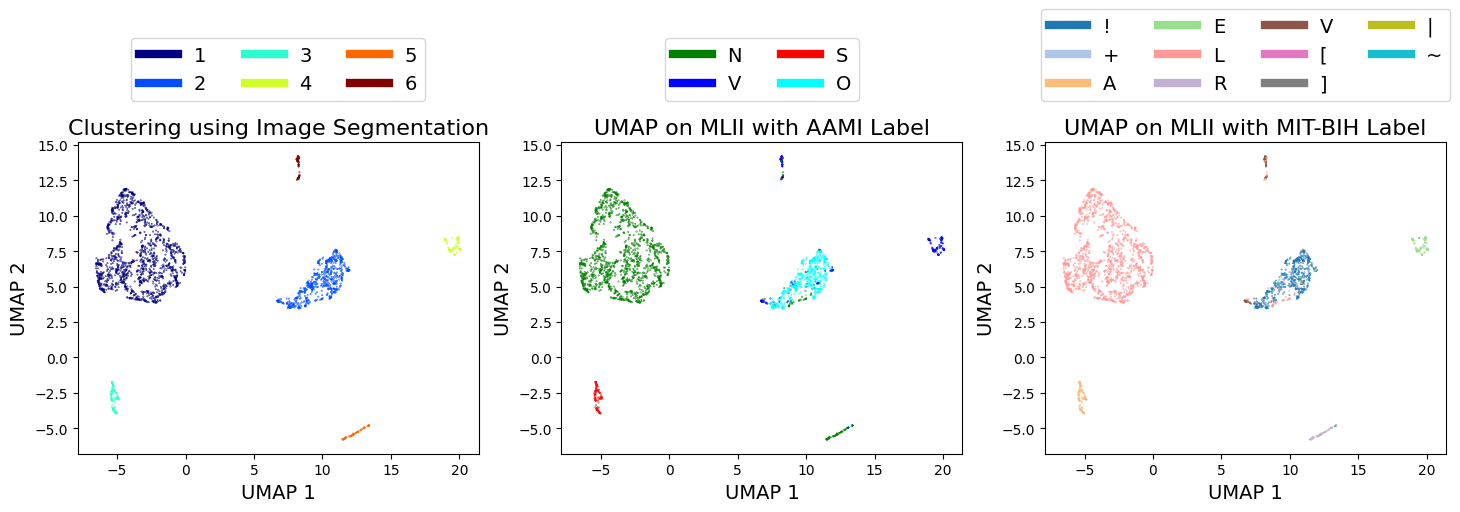

In [42]:
# Define colors for AAMI labels: 'N', 'V', 'S', 'F', 'U', 'O'
label_colors = ['green', 'blue', 'red', 'purple', 'orange', 'cyan']

# Create figure with 1x3 subplots
fig3, axs = plt.subplots(1, 3, figsize=(15, 5))

# --- First subplot: Clustering using Image Segmentation ---
scatter1 = axs[0].scatter(y_selected[:, 0], y_selected[:, 1], c=point_labels, s=0.1, cmap='jet')
axs[0].set_xlabel("UMAP 1", fontsize=14)
axs[0].set_ylabel("UMAP 2", fontsize=14)
axs[0].set_title("Clustering using Image Segmentation", fontsize=16)

# Manual legend for clustering
unique_cluster_labels = np.unique(point_labels)
jet_cmap = plt.get_cmap('jet')
norm = plt.Normalize(vmin=min(unique_cluster_labels), vmax=max(unique_cluster_labels))
cluster_color_map = {label: jet_cmap(norm(label)) for label in unique_cluster_labels}

legend_handles_cluster = [
    mlines.Line2D([0], [0], color=cluster_color_map[label], lw=6, label=str(label + 1))
    for label in unique_cluster_labels
]
axs[0].legend(handles=legend_handles_cluster, title='', loc='lower center',
              bbox_to_anchor=(0.5, 1.1), fontsize=14, ncol=3)

# --- Second subplot: UMAP with AAMI Labels ---
unique_labels = np.unique(ecg_labels)
color_mapping = {label: label_colors[label] for label in unique_labels}
colors = [color_mapping[label] for label in ecg_labels]

axs[1].scatter(y_selected[:, 0], y_selected[:, 1], s=0.1, c=colors)
axs[1].set_xlabel("UMAP 1", fontsize=14)
axs[1].set_ylabel("UMAP 2", fontsize=14)
axs[1].set_title(f'{dimensionality_reduction} on {channel} with AAMI Label', fontsize=16)

label_names = ['N', 'V', 'S', 'F', 'U', 'O']
legend_elements = [
    mlines.Line2D([0], [0], color=label_colors[idx], lw=6, label=label_names[idx])
    for idx in unique_labels
]
axs[1].legend(handles=legend_elements, title='', loc='lower center',
              bbox_to_anchor=(0.5, 1.1), fontsize=14, ncol=2)

# --- Third subplot: UMAP with MIT-BIH Labels ---
labels = mitbih_labels # Make sure it's defined
unique_labels = np.unique(labels)
cmap_name = 'tab10' if len(unique_labels) <= 10 else 'tab20'
cmap = plt.get_cmap(cmap_name)
label_to_color = {label: cmap(j / len(unique_labels)) for j, label in enumerate(unique_labels)}
colors = np.array([label_to_color[label] for label in labels])

axs[2].scatter(y_selected[:, 0], y_selected[:, 1], s=0.1, c=colors)
axs[2].set_xlabel("UMAP 1", fontsize=14)
axs[2].set_ylabel("UMAP 2", fontsize=14)
axs[2].set_title(f'{dimensionality_reduction} on {channel} with MIT-BIH Label', fontsize=16)

legend_handles = [mlines.Line2D([0], [0], color=label_to_color[l], lw=6, label=l) for l in unique_labels]
axs[2].legend(handles=legend_handles, title='', loc='lower center',
              bbox_to_anchor=(0.5, 1.1), fontsize=14, ncol=4)

# Layout adjustments
fig3.tight_layout()
fig3.subplots_adjust(top=0.75)  # space for legends
plt.show()

#### **4.4.6 Visualizing Beats for each Cluster**

0 (1398, 256) (256,)
1 (631, 256) (256,)
2 (113, 256) (256,)
3 (96, 256) (256,)
4 (76, 256) (256,)
5 (69, 256) (256,)


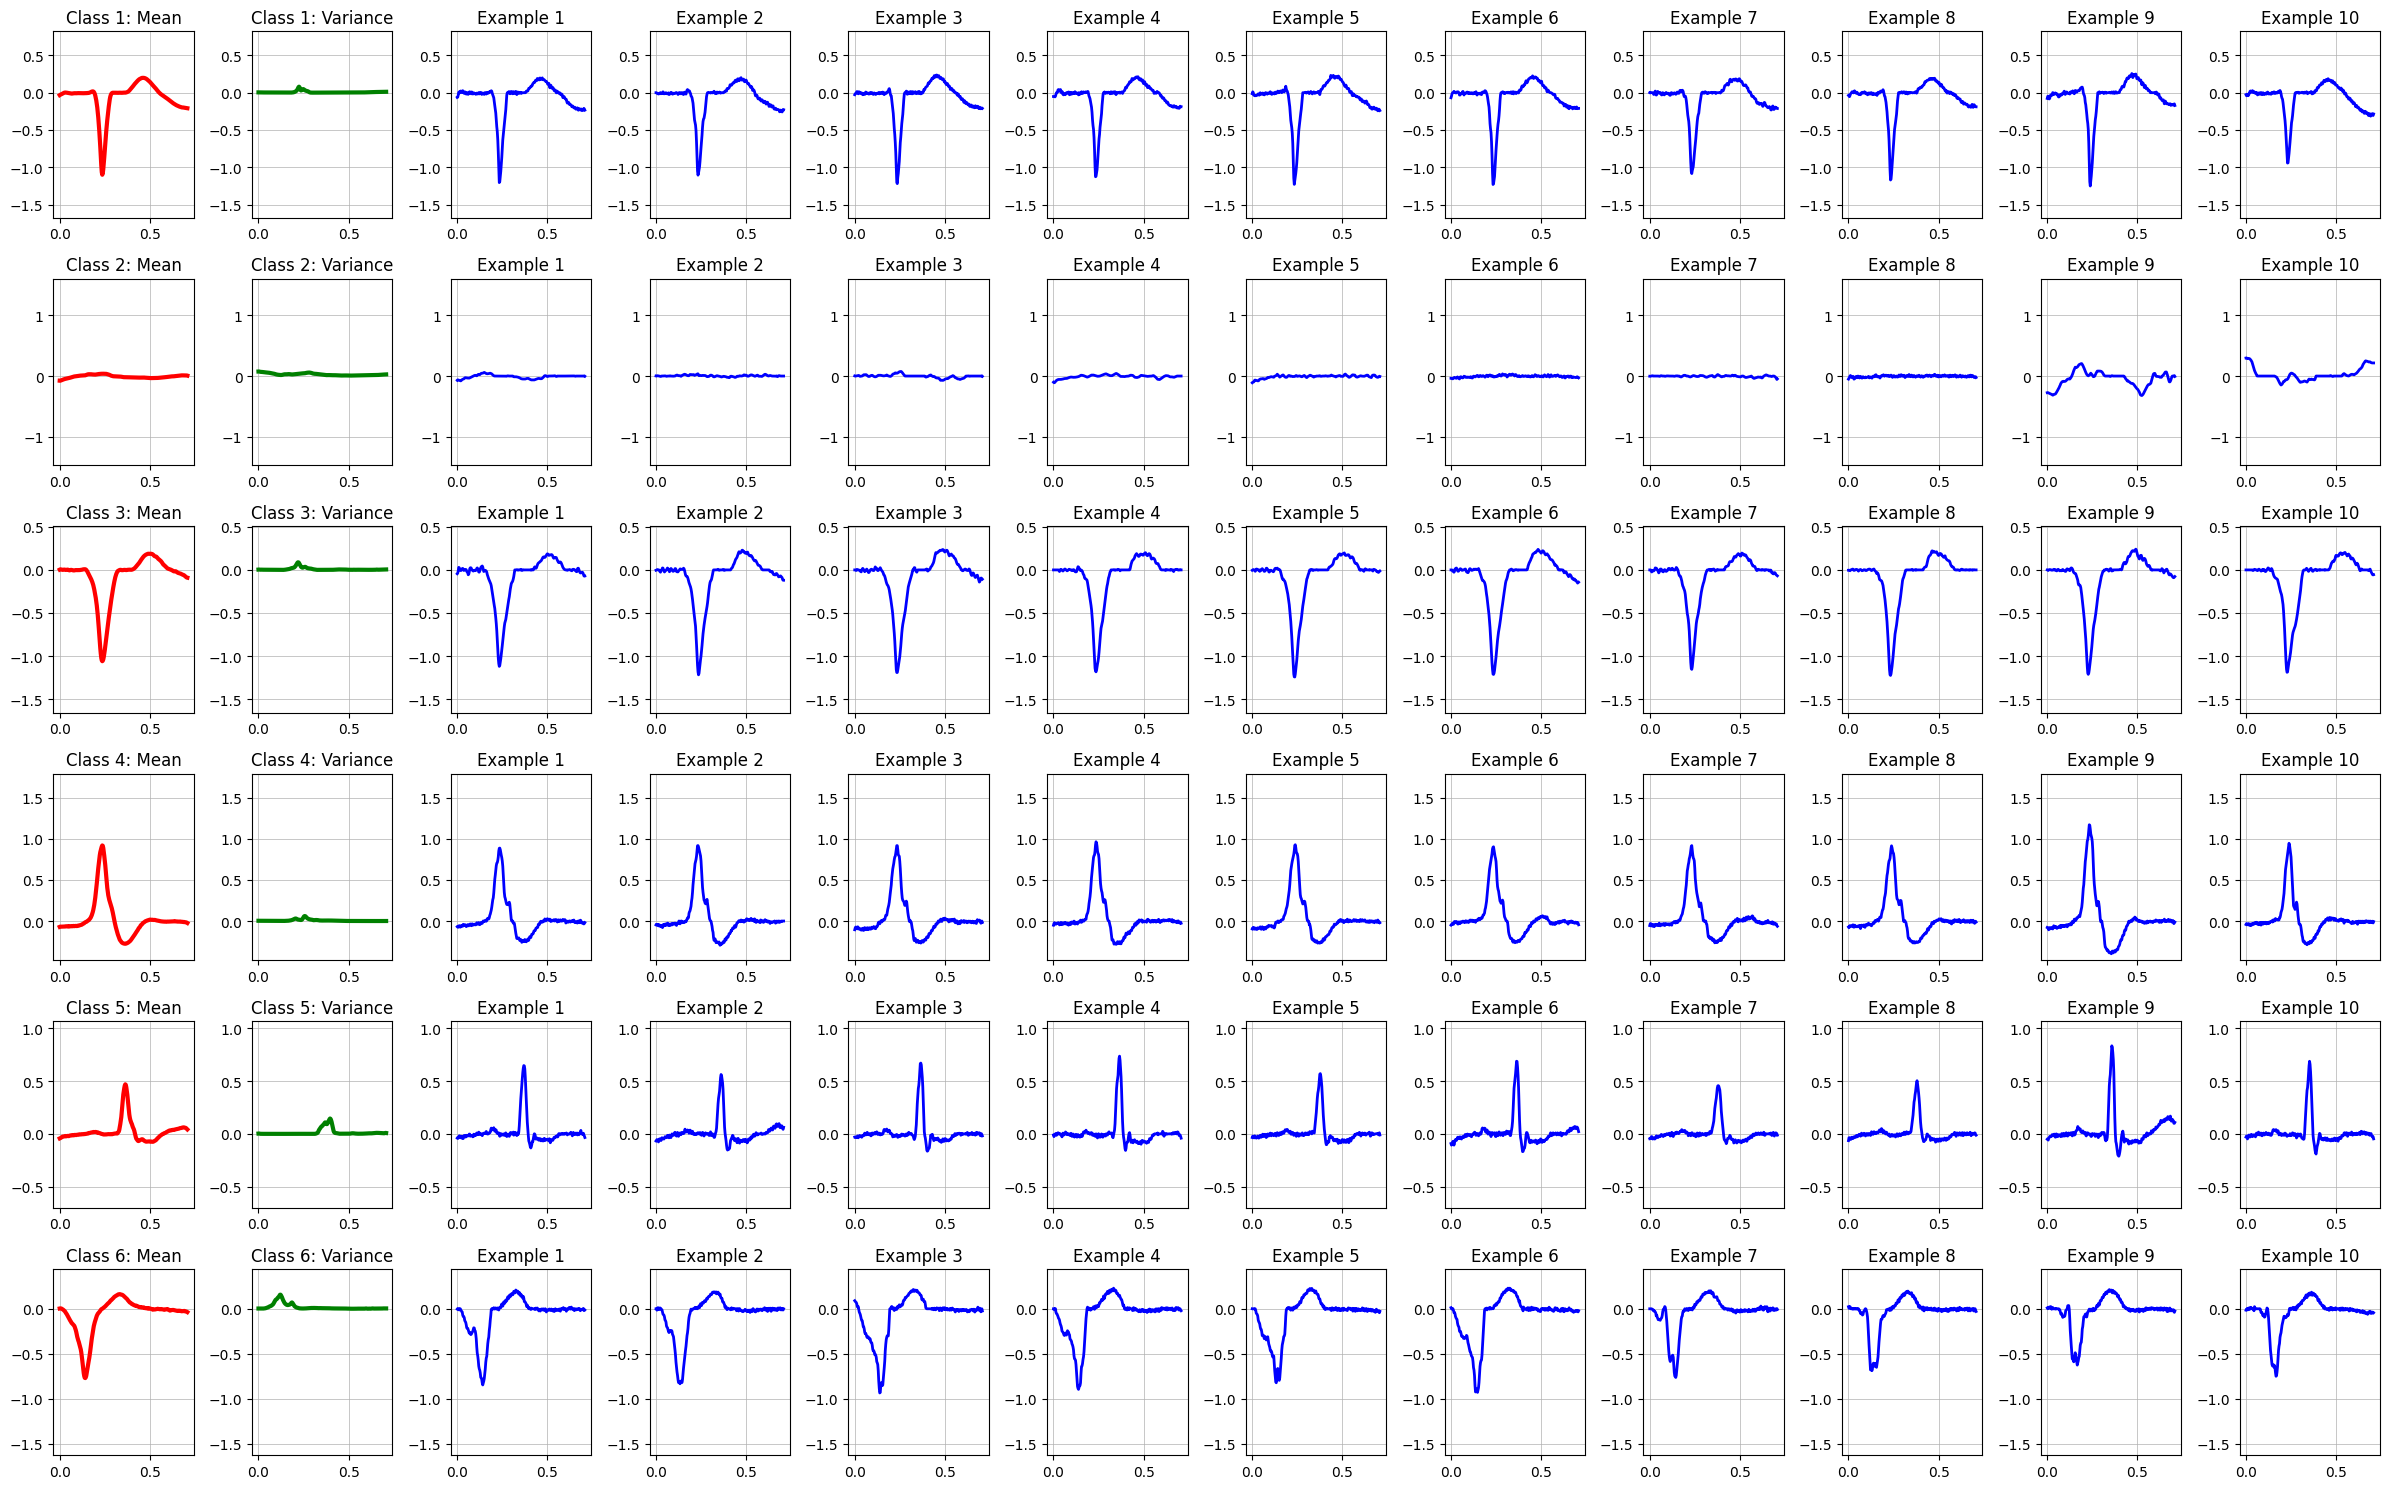

In [43]:
# Sampling frequency (Hz)
fs = 360

# Unique cluster labels
unique_labels = np.unique(point_labels)
num_classes = len(unique_labels)

# Create 12 columns: mean, variance, and 10 examples
fig4, axes = plt.subplots(num_classes, 12, figsize=(24, 2.5 * num_classes))

# Time vector for plotting
time_vector = np.arange(ecg_recording.shape[1]) / fs

for i, label in enumerate(unique_labels):
    # Extract signals for current class
    class_signals = ecg_recording[point_labels == label]
    avg_signal = np.mean(class_signals, axis=0)
    var_signal = np.var(class_signals, axis=0)
    print(label, np.shape(class_signals), np.shape(avg_signal))

    # Y-axis limits
    y_min = np.min(class_signals)
    y_max = np.max(class_signals)

    # Plot mean
    axes[i, 0].plot(time_vector, avg_signal, color='red', linewidth=3)
    axes[i, 0].set_title(f'Class {label+1}: Mean', fontsize=12)
    axes[i, 0].set_ylim(y_min, y_max)
    axes[i, 0].grid(True, which='both', linestyle='-', linewidth=0.5)

    # Plot variance
    axes[i, 1].plot(time_vector, var_signal, color='green', linewidth=3)
    axes[i, 1].set_title(f'Class {label+1}: Variance', fontsize=12)
    axes[i, 1].set_ylim(y_min, y_max)
    axes[i, 1].grid(True, which='both', linestyle='-', linewidth=0.5)

    # --- Compute similarity (Euclidean distance) ---
    distances = np.linalg.norm(class_signals - avg_signal, axis=1)
    sorted_indices = np.argsort(distances)

    # 8 most similar
    top8 = sorted_indices[:8]

    # 2 median examples
    mid_pos = len(sorted_indices) // 2
    median2 = sorted_indices[mid_pos-1:mid_pos+1]

    # Combine into 10 total
    selected_indices = np.concatenate([top8, median2])

    # Plot 10 random signals
    # num_examples = min(10, class_signals.shape[0])
    # selected_indices = np.random.choice(class_signals.shape[0], num_examples, replace=False)

    # Plot selected signals
    for j, idx in enumerate(selected_indices):
        axes[i, j + 2].plot(time_vector, class_signals[idx], color='blue', linewidth=2)
        axes[i, j + 2].set_title(f'Example {j+1}', fontsize=12)
        axes[i, j + 2].set_ylim(y_min, y_max)
        axes[i, j + 2].grid(True, which='both', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

#### **4.4.7 Robustness Across Different Hyperparameters**

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


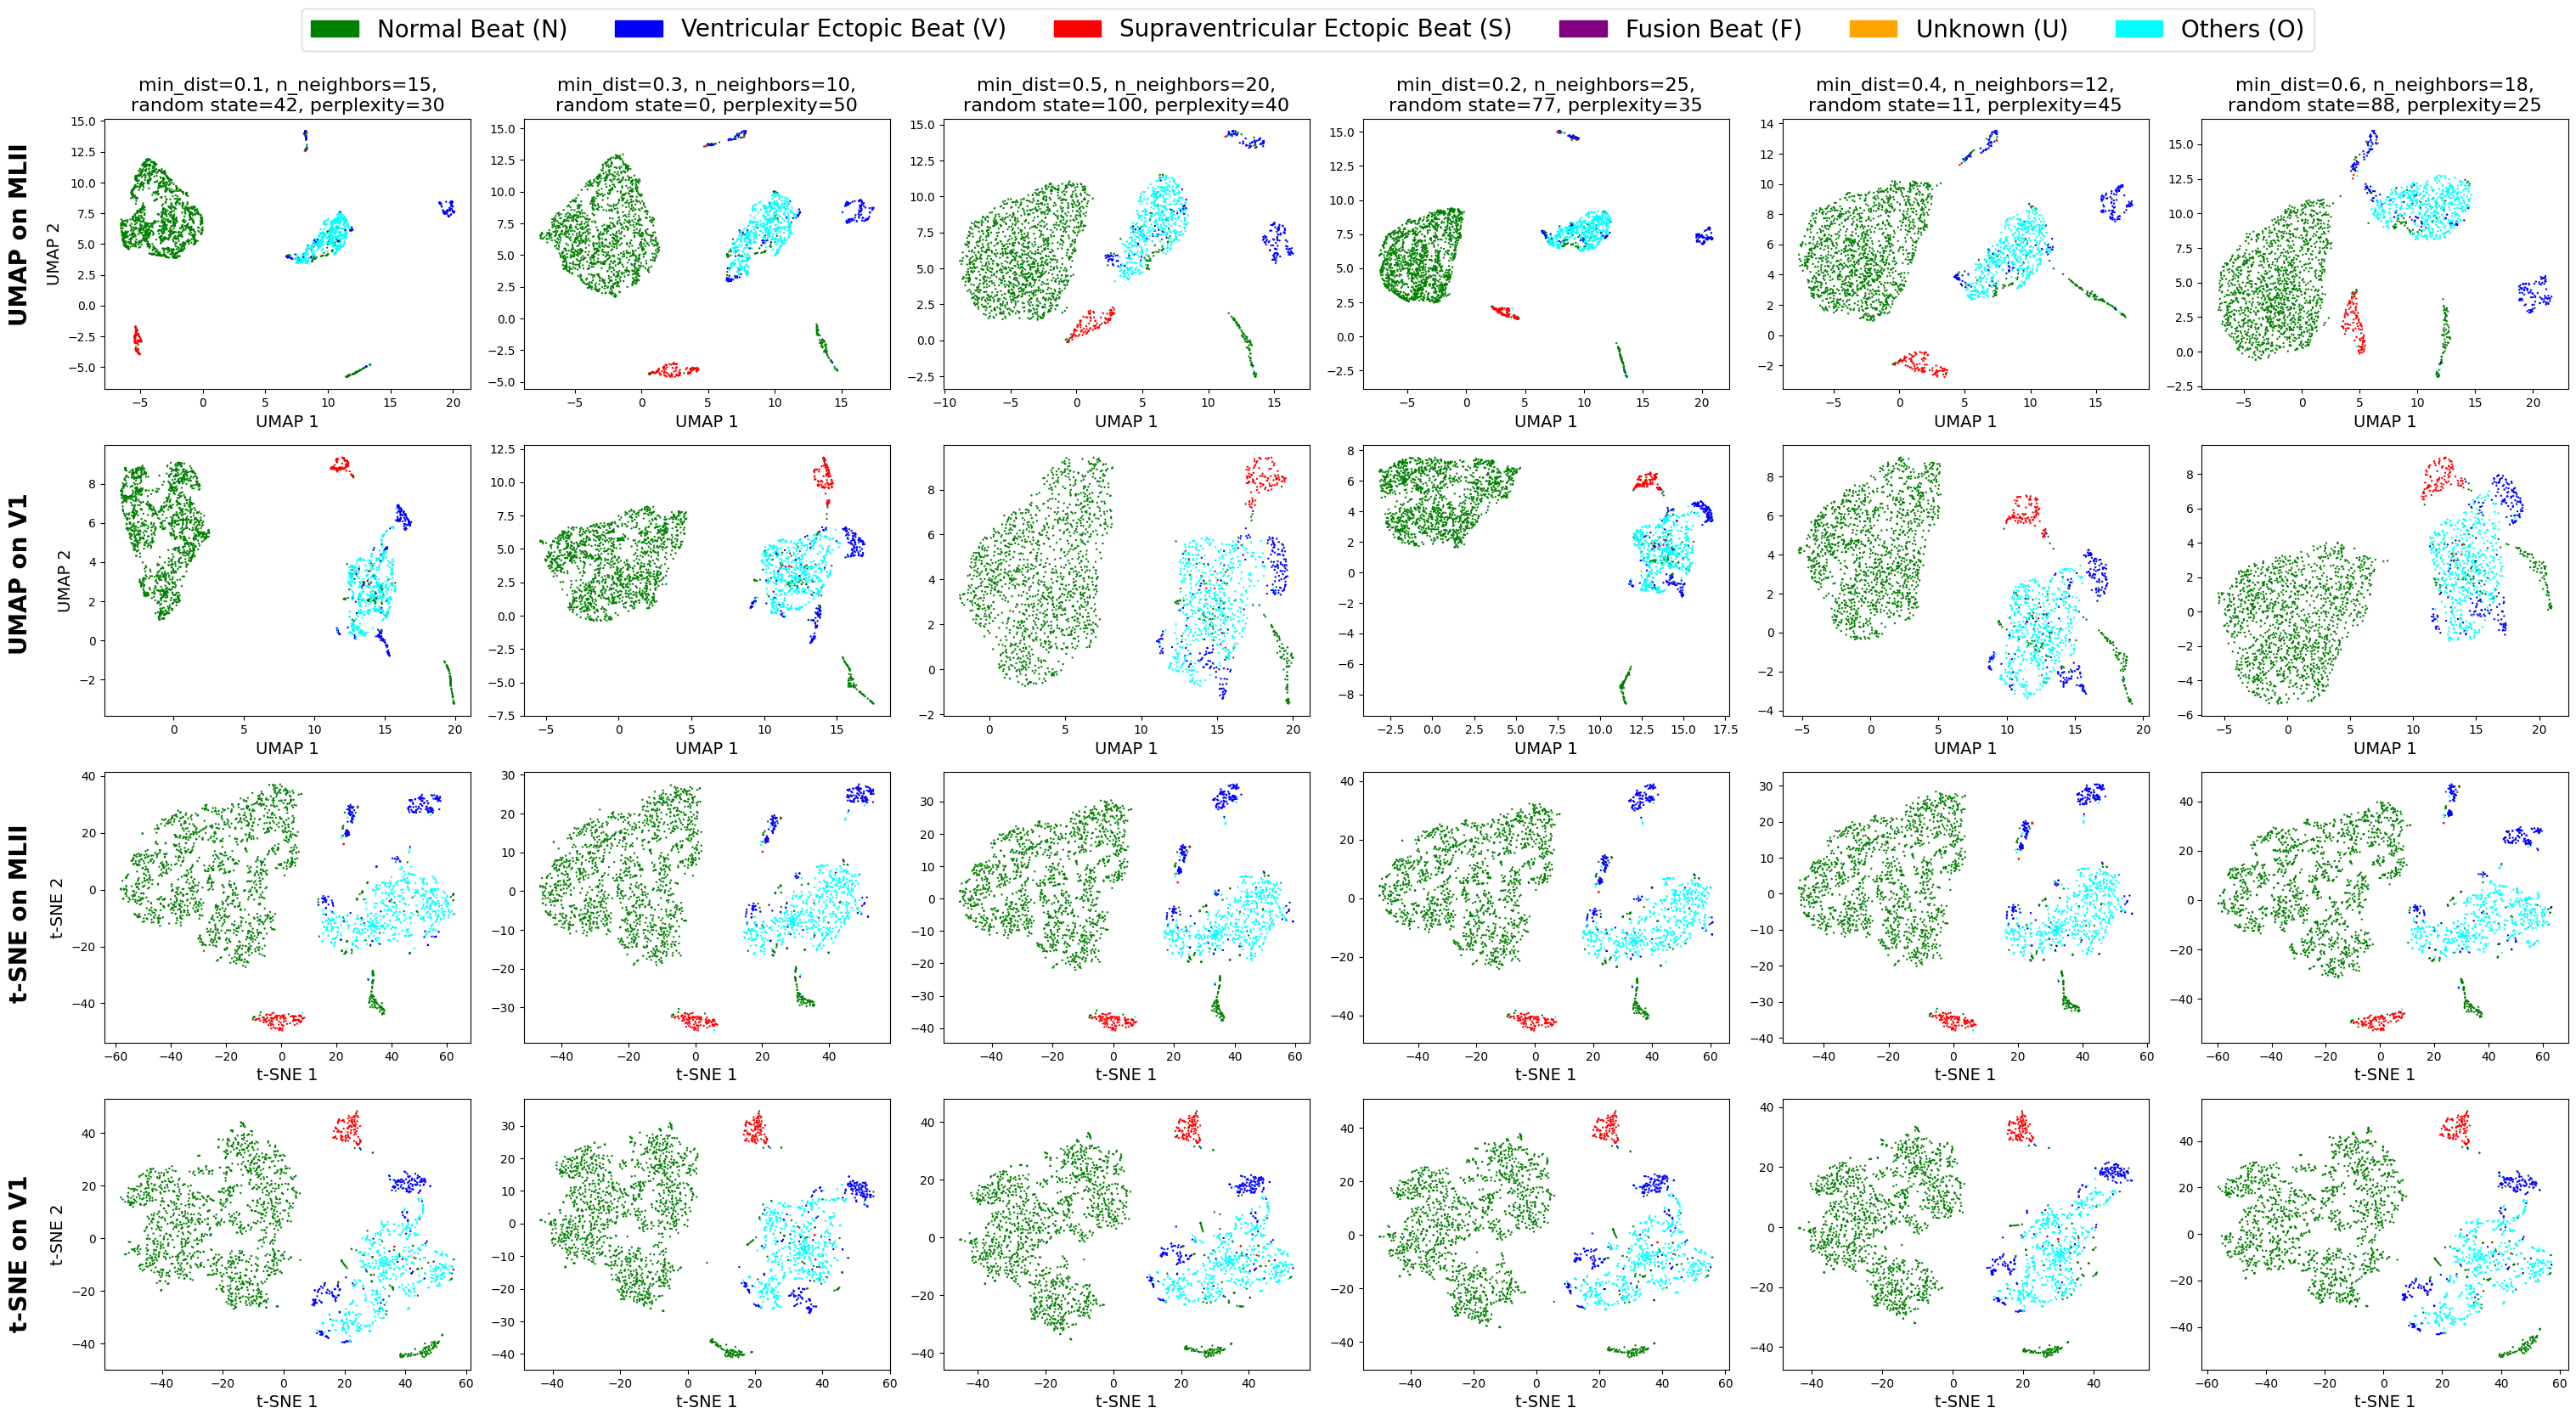

In [ ]:
# Define setups
setups = [
    {'min_dist': 0.1, 'n_neighbors': 15, 'random_state': 42,  'perplexity': 30},
    {'min_dist': 0.3, 'n_neighbors': 10, 'random_state': 0,   'perplexity': 50},
    {'min_dist': 0.5, 'n_neighbors': 20, 'random_state': 100, 'perplexity': 40},
    {'min_dist': 0.2, 'n_neighbors': 25, 'random_state': 77,  'perplexity': 35},
    {'min_dist': 0.4, 'n_neighbors': 12, 'random_state': 11,  'perplexity': 45},
    {'min_dist': 0.6, 'n_neighbors': 18, 'random_state': 88,  'perplexity': 25},
]

# Colors
colors = ['green', 'blue', 'red', 'purple', 'orange', 'cyan']
cmap = mcolors.ListedColormap(colors)

# Step 1: Compute and store results
results = []
for params in setups:
    umap_mlii, umap_v1, tsne_mlii, tsne_v1, _, _ = compute_embeddings(
        ECG_MLII, ECG_V1,
        min_dist=params['min_dist'],
        n_neighbors=params['n_neighbors'],
        random_state=params['random_state'],
        perplexity=params['perplexity']
    )
    results.append({
        "params": params,
        "umap_mlii": umap_mlii,
        "umap_v1": umap_v1,
        "tsne_mlii": tsne_mlii,
        "tsne_v1": tsne_v1
    })


# Step 2: Function to plot stored results
def plot_results(results):
    fig, axes = plt.subplots(4, len(results), figsize=(5*len(results), 16))

    # ----- Legend setup -----
    colors = ['green', 'blue', 'red', 'purple', 'orange', 'cyan']
    classes = ['Normal Beat (N)', 'Ventricular Ectopic Beat (V)', 'Supraventricular Ectopic Beat (S)',
               'Fusion Beat (F)', 'Unknown (U)', 'Others (O)']
    cmap = mcolors.ListedColormap(colors)
    legend_handles = [mpatches.Patch(color=colors[i], label=classes[i]) for i in range(len(classes))]

    for col, res in enumerate(results):
        p = res["params"]

        # Title per column
        axes[0, col].set_title(
            f"min_dist={p['min_dist']}, "
            f"n_neighbors={p['n_neighbors']},\n"
            f"random state={p['random_state']}, "
            f"perplexity={p['perplexity']}",
            fontsize=16
        )

        # Row 1: UMAP MLII
        axes[0, col].scatter(res["umap_mlii"][:, 0], res["umap_mlii"][:, 1],
                             c=aami_labels, cmap=cmap, s=0.5)
        axes[0, col].set_xlabel('UMAP 1', fontsize=14)
        if col == 0:
            axes[0, col].set_ylabel('UMAP 2', fontsize=14)

        # Row 2: UMAP V1
        axes[1, col].scatter(res["umap_v1"][:, 0], res["umap_v1"][:, 1],
                             c=aami_labels, cmap=cmap, s=0.5)
        axes[1, col].set_xlabel('UMAP 1', fontsize=14)
        if col == 0:
            axes[1, col].set_ylabel('UMAP 2', fontsize=14)

        # Row 3: t-SNE MLII
        axes[2, col].scatter(res["tsne_mlii"][:, 0], res["tsne_mlii"][:, 1],
                             c=aami_labels, cmap=cmap, s=0.5)
        axes[2, col].set_xlabel('t-SNE 1', fontsize=14)
        if col == 0:
            axes[2, col].set_ylabel('t-SNE 2', fontsize=14)

        # Row 4: t-SNE V1
        axes[3, col].scatter(res["tsne_v1"][:, 0], res["tsne_v1"][:, 1],
                             c=aami_labels, cmap=cmap, s=0.5)
        axes[3, col].set_xlabel('t-SNE 1', fontsize=14)
        if col == 0:
            axes[3, col].set_ylabel('t-SNE 2', fontsize=14)

    # --- Figure-level row labels ---
    row_labels = ["UMAP on MLII", "UMAP on V1", "t-SNE on MLII", "t-SNE on V1"]
    for row, label in enumerate(row_labels):
        y_coord = (4 - row) / 4 - 0.125
        fig.text(-0.01, y_coord, label, va='center', ha='left',
                 fontsize=20, fontweight='bold', rotation='vertical')

    # --- Global legend at top ---
    fig.legend(handles=legend_handles, loc='upper center',
               bbox_to_anchor=(0.5, 1.05), ncol=6, fontsize=20)

    plt.tight_layout()
    plt.show()


# Step 3: Call plotting function
plot_results(results)